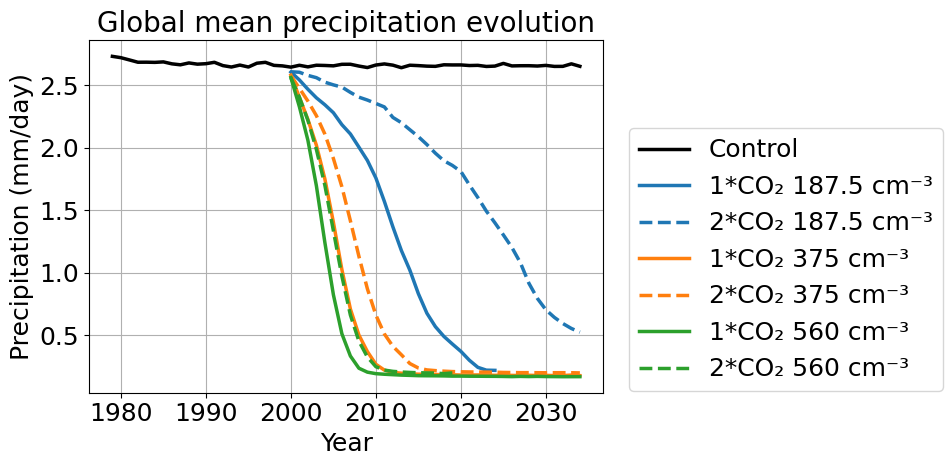

In [14]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.stats import ttest_ind
from cartopy.util import add_cyclic_point 
import matplotlib.patches as mpatches

import sys
sys.path.append("/gpfs/data/fs72044/avoigt_teach/msc-climodlab-s2026/msc-climate-modeling-lab-s2026-code4students/analysis/")
import core as core

def load_dataset(path, file):
    ds = xr.open_dataset(path + file)
    ds = core.correct_timeaxis(ds)

    # Convert precipitation to mm/day
    for var in ["pr", "prcr", "prcs"]:
        ds[var] = ds[var] * 86400
        ds[var].attrs["units"] = "mm/day"

    return ds

ds_ctr = load_dataset(
    "/gpfs/data/fs72044/avoigt_teach/experiments/s2026/slabctr/",
    "slabctr_atm_2d_ml_1979-2035.remapcon-r360x180.nc"
)

ds_375_2co2 = load_dataset(
    "/gpfs/data/fs72044/icon15/simulations/slab375_2co2/",
    "slab375_2co2_atm_2d_2000_2035_remap.nc"
)

ds_375_1co2 = load_dataset(
    "/gpfs/data/fs72044/icon18/experiments/s2026/slabcn2sea375/",
    "slab375_1co2_2d_2000_2035.cell_area.r360x180.nc"
)

ds_187_1co2 = load_dataset(
    "/gpfs/data/fs72044/icon15/simulations/slab187_1co2/",
    "slab187_1co2_atm_2d_2000_2025_remap_sic.nc"
)

ds_187_2co2 = load_dataset(
    "/gpfs/data/fs72044/icon15/simulations/slab187_2co2/",
    "slab187_2co2_atm_2d_2000_2035_remap.nc"
)

ds_560_1co2 = load_dataset(
    "/gpfs/data/fs72044/icon28/Simulations/slabcn560/",
    "slabcn560_1co2_2d_2000-2035_remapped.nc"
)

ds_560_2co2 = load_dataset(
    "/gpfs/data/fs72044/icon28/Simulations/slabcn560doubledco2/",
    "slabcn560doubledco2_2d_2000_2019_remapped.nc"
)

ds_187_1co2 = xr.Dataset(
    {
        "pr": ds_187_1co2["pr"][0:310],
        "prcr": ds_187_1co2["prcr"][0:310],
        "prcs": ds_187_1co2["prcs"][0:310],
    }
)

ds_ctr = xr.Dataset(
    {
        "pr": ds_ctr["pr"][1:],
        "prcr": ds_ctr["prcr"][1:],
        "prcs": ds_ctr["prcs"][1:],
    }
)

# ============================================================
# Plot styling
# ============================================================

STYLE_DICT = {
    "Control": {
        "color": "black",
        "linestyle": "-",
        "linewidth": 2.5
    },

    "1*CO₂ 187.5 cm⁻³": {
        "color": "tab:blue",
        "linestyle": "-",
        "linewidth": 2.5
    },
    
    "2*CO₂ 187.5 cm⁻³": {
        "color": "tab:blue",
        "linestyle": "--",
        "linewidth": 2.5
    },
    
    "1*CO₂ 375 cm⁻³": {
        "color": "tab:orange",
        "linestyle": "-",
        "linewidth": 2.5
    },

    "2*CO₂ 375 cm⁻³": {
        "color": "tab:orange",
        "linestyle": "--",
        "linewidth": 2.5
    },

    "1*CO₂ 560 cm⁻³": {
        "color": "tab:green",
        "linestyle": "-",
        "linewidth": 2.5
    },

    "2*CO₂ 560 cm⁻³": {
        "color": "tab:green",
        "linestyle": "--",
        "linewidth": 2.5
    }
}

# ============================================================
# Global fontsize settings
# ============================================================

plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16
})

def global_annual_mean(ds, var):
    gm = core.global_mean(ds[var])
    return gm.groupby("time.year").mean("time")

def plot_precip_timeseries(datasets, labels, var="pr", title=""):

    plt.figure(figsize=(10,5))

    for ds, label in zip(datasets, labels):

        ts = global_annual_mean(ds, var)

        style = STYLE_DICT[label]

        plt.plot(
            ts.year,
            ts,
            label=label,
            color=style["color"],
            linestyle=style["linestyle"],
            linewidth=style["linewidth"]
        )

    plt.xlabel("Year", fontsize=18)
    plt.ylabel("Precipitation (mm/day)", fontsize=18)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.title(title, fontsize=20)
    plt.legend(bbox_to_anchor=(1.05, 0.75), loc='upper left', borderaxespad=0., fontsize=18)
    plt.grid()
    
    plt.tight_layout()
    plt.savefig('Precipitation_timeseires.pdf')
    plt.show()
    
plot_precip_timeseries(
    [ds_ctr, ds_187_1co2, ds_187_2co2, ds_375_1co2, ds_375_2co2, ds_560_1co2, ds_560_2co2],
    ["Control", "1*CO₂ 187.5 cm⁻³", "2*CO₂ 187.5 cm⁻³", "1*CO₂ 375 cm⁻³", "2*CO₂ 375 cm⁻³", "1*CO₂ 560 cm⁻³", "2*CO₂ 560 cm⁻³"],
    var="pr",
    title='Global mean precipitation evolution'
)

def plot_precip_map(ds, var="pr", years=("2000","2014"), title=""):

    field = ds[var].sel(time=slice(*years)).mean("time")
    
    field_cyclic, lon_cyclic = add_cyclic_point(field.values, coord=ds.lon.values)


    fig = plt.figure(figsize=(12,5))

    ax = plt.axes(projection=ccrs.EqualEarth())

    im = ax.contourf(
        lon_cyclic,
        ds.lat,
        field_cyclic,
        levels=np.linspace(0, 15, 21),
        transform=ccrs.PlateCarree(),
        cmap="Blues"
    )

    ax.coastlines()
    ax.set_global()
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)

    #plt.colorbar(im, ax=ax, label="mm/day")
    cbar = plt.colorbar(im, ax=ax)

    cbar.set_label("mm/day", fontsize=18)
    cbar.ax.tick_params(labelsize=16)

    plt.title(title)

    plt.show()
    
def plot_precip_anomaly(ds_exp, ds_ctr, var="pr", years=("2000","2014")):

    exp = ds_exp[var].sel(time=slice(*years)).mean("time")
    ctr = ds_ctr[var].sel(time=slice(*years)).mean("time")

    anomaly = exp - ctr

    fig = plt.figure(figsize=(12,5))

    ax = plt.axes(projection=ccrs.EqualEarth())

    levels = np.linspace(-5,5,21)

    im = ax.contourf(
        ds_ctr.lon,
        ds_ctr.lat,
        anomaly,
        levels=levels,
        cmap="RdBu_r",
        extend="both",
        transform=ccrs.PlateCarree()
    )

    ax.coastlines()
    ax.set_global()

    plt.colorbar(im, ax=ax, label=r"$\Delta$ mm/day")

    plt.title(f"{var}: experiment - control")

    plt.show()
    
def plot_zonal_mean(ds_list, labels, var="pr", title=""):

    plt.figure(figsize=(8,5))

    for ds, label in zip(ds_list, labels):

        zonal = ds[var].mean("lon").mean("time")

        #plt.plot(ds.lat, zonal, label=label)
        style = STYLE_DICT[label]

        plt.plot(
            ds.lat,
            zonal,
            label=label,
            color=style["color"],
            linestyle=style["linestyle"],
            linewidth=style["linewidth"]
        )

    plt.xlabel("Latitude", fontsize=18)
    plt.ylabel("mm/day", fontsize=18)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.title(title, fontsize=20)
    #plt.legend(bbox_to_anchor=(1.05, 0.75), loc='upper left', borderaxespad=0., fontsize=18)
    plt.grid()

    plt.tight_layout()
    plt.savefig('zonal_mean_precipitation.pdf')
    plt.show()
    
def plot_convective_fraction(ds_list, labels, title=""):

    plt.figure(figsize=(8,5))

    for ds, label in zip(ds_list, labels):

        frac = (ds["prcr"] / ds["pr"]).mean("lon").mean("time")

        #plt.plot(ds.lat, frac, label=label)
        style = STYLE_DICT[label]

        plt.plot(
        ds.lat,
        frac,
        label=label,
        color=style["color"],
        linestyle=style["linestyle"],
        linewidth=style["linewidth"]
    )

    plt.xlabel("Latitude", fontsize=18)
    plt.ylabel("Ratio (Rain)", fontsize=18)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.grid()
    plt.title(title, fontsize=20)
    #plt.legend(bbox_to_anchor=(1.05, 0.75), borderaxespad=0., fontsize=18)

    plt.tight_layout()
    plt.savefig('convective_precipitation_fraction.pdf')
    plt.show()
    
def plot_stratiform_precipitation_fraction(ds_list, labels, title=""):

    plt.figure(figsize=(8,5))

    for ds, label in zip(ds_list, labels):

        frac = (ds["prcs"] / ds["pr"]).mean("lon").mean("time")

        #plt.plot(ds.lat, frac, label=label)
        style = STYLE_DICT[label]

        plt.plot(
            ds.lat,
            frac,
            label=label,
            color=style["color"],
            linestyle=style["linestyle"],
            linewidth=style["linewidth"]
        )

    plt.xlabel("Latitude", fontsize=18)
    plt.ylabel("Ratio (Snow)", fontsize=18)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.grid()
    plt.title(title, fontsize=20)
    #plt.legend(bbox_to_anchor=(1.05, 0.75), loc='upper left', borderaxespad=0., fontsize=18)

    plt.tight_layout()
    #plt.savefig('Stratiform_peecipitation_fraction.pdf')
    plt.show()
    
def extreme_precip(ds, var="pr", q=0.99):

    return ds[var].quantile(q, dim="time")

def global_monthly_climatology(ds, var="pr"):

    gm = core.global_mean(ds[var])

    clim = gm.groupby("time.month").mean("time")

    return clim

def plot_monthly_climatology(ds_list, labels, var="pr"):

    plt.figure(figsize=(10,5))

    months = np.arange(1,13)

    for ds, label in zip(ds_list, labels):

        clim = global_monthly_climatology(ds, var)

        #plt.scatter(months, clim, marker="o", label=label)
        style = STYLE_DICT[label]

        plt.plot(
            months,
            clim,
            label=label,
            color=style["color"],
            linestyle=style["linestyle"],
            linewidth=style["linewidth"]
        )

    plt.xticks(months)

    plt.xlabel("Month")
    plt.ylabel(f"{var} (mm/day)")
    plt.title(f"Global monthly climatology of {var}")

    plt.grid()
    plt.legend()

    plt.show()
    
def seasonal_zonal_mean(ds, var="pr"):

    monthly = ds[var].groupby("time.month").mean("time")

    weights = np.cos(np.deg2rad(ds.lat))
    zonal = ds[var].weighted(weights).mean("lon")

    return zonal

def plot_seasonal_zonal(ds, var="pr", title=""):

    zonal = seasonal_zonal_mean(ds, var)

    fig, ax = plt.subplots(figsize=(12,6))
    
    levels = np.linspace(0,10,21)

    im = ax.contourf(
        zonal.lat,
        zonal['time.month'],
        zonal,
        levels=levels,
        cmap="Blues"
    )

    #plt.colorbar(im, ax=ax, label="mm/day")
    cbar = plt.colorbar(im, ax=ax)

    cbar.set_label("mm/day", fontsize=18)
    cbar.ax.tick_params(labelsize=16)

    ax.set_xlabel("Latitude")
    ax.set_ylabel("Month")

    ax.set_title(title)

    plt.show()
    
def plot_seasonal_zonal_anomaly(ds_exp, ds_ctr, var="pr", title=""):

    zonal_exp = seasonal_zonal_mean(ds_exp, var)
    zonal_ctr = seasonal_zonal_mean(ds_ctr, var)

    anomaly = zonal_exp - zonal_ctr

    fig, ax = plt.subplots(figsize=(12,6))

    levels = np.linspace(-3,3,21)

    im = ax.contourf(
        anomaly.lat,
        anomaly['time.month'],
        anomaly,
        levels=levels,
        cmap="RdBu_r",
        extend="both"
    )

    plt.colorbar(im, ax=ax, label=r"$\Delta$ mm/day")

    ax.set_xlabel("Latitude")
    ax.set_ylabel("Month")

    ax.set_title(title)

    plt.show()
    
def compute_ttest(ds_exp, ds_ctr, var="pr", years=("2000","2014")):

    exp = ds_exp[var].sel(time=slice(*years))
    ctr = ds_ctr[var].sel(time=slice(*years))

    # scipy t-test
    tstat, pval = ttest_ind(
        exp,
        ctr,
        axis=0,
        equal_var=False,
        nan_policy="omit"
    )

    return xr.DataArray(
        pval,
        coords={
            "lat": ds_exp.lat,
            "lon": ds_exp.lon
        },
        dims=["lat","lon"]
    )

def plot_precip_anomaly_significance(
    ds_exp,
    ds_ctr,
    var="pr",
    years=("2000","2014"),
    title=''
):

    # means
    exp_mean = ds_exp[var].sel(time=slice(*years)).mean("time")
    ctr_mean = ds_ctr[var].sel(time=slice(*years)).mean("time")

    anomaly = exp_mean - ctr_mean
    
    anomaly_cyclic, lon_cyclic = add_cyclic_point(anomaly.values, coord=ds_exp.lon.values)

    # significance
    pval = compute_ttest(ds_exp, ds_ctr, var, years)

    sig = pval > 0.05

    fig = plt.figure(figsize=(13,6))

    ax = plt.axes(projection=ccrs.EqualEarth())

    levels = np.linspace(-5,5,21)

    im = ax.contourf(
        lon_cyclic,
        ds_exp.lat,
        anomaly_cyclic,
        levels=levels,
        cmap="RdBu_r",
        extend="both",
        transform=ccrs.PlateCarree()
    )

    # significance hatching
    ax.contourf(
        ds_exp.lon,
        ds_exp.lat,
        sig,
        levels=[0.5,1],
        hatches=["...."],
        colors="none",
        label='Not significant at 5%',
        transform=ccrs.PlateCarree()
    )
    
    patch_sig = mpatches.Patch(
        facecolor="none",
        edgecolor="black",
        hatch="....",
        label="Not significant at 5%",
    )

    ax.coastlines()
    ax.set_global()

    plt.colorbar(im, ax=ax, label="Precipitation anomaly (mm/day)")
    plt.title(title, fontsize=20)
    plt.legend(handles=[patch_sig], bbox_to_anchor=(0.75, -0.05), fontsize=18)

    #plt.savefig('Precipitation_timeseires.pdf')
    plt.show()
    
def seasonal_mean(ds, var="pr"):

    return ds[var].groupby("time.season").mean("time")

def plot_seasonal_anomalies(ds_exp, ds_ctr, var="pr"):

    exp = ds_exp[var].groupby("time.season").mean("time")
    ctr = ds_ctr[var].groupby("time.season").mean("time")

    anomaly = exp - ctr

    seasons = ["DJF", "MAM", "JJA", "SON"]

    fig, axes = plt.subplots(
        2,2,
        figsize=(14,8),
        subplot_kw={"projection": ccrs.PlateCarree()}
    )

    levels = np.linspace(-5,5,21)

    for ax, season in zip(axes.flat, seasons):

        im = ax.contourf(
            ds_exp.lon,
            ds_exp.lat,
            anomaly.sel(season=season),
            levels=levels,
            cmap="RdBu_r",
            extend="both",
            transform=ccrs.PlateCarree()
        )

        ax.coastlines()
        ax.set_global()

        ax.set_title(season)

    cbar = plt.colorbar(im, ax=axes.ravel().tolist())

    cbar.set_label(r"$\Delta$ mm/day")

    plt.suptitle(f"Seasonal precipitation anomalies ({var})")

    plt.show()

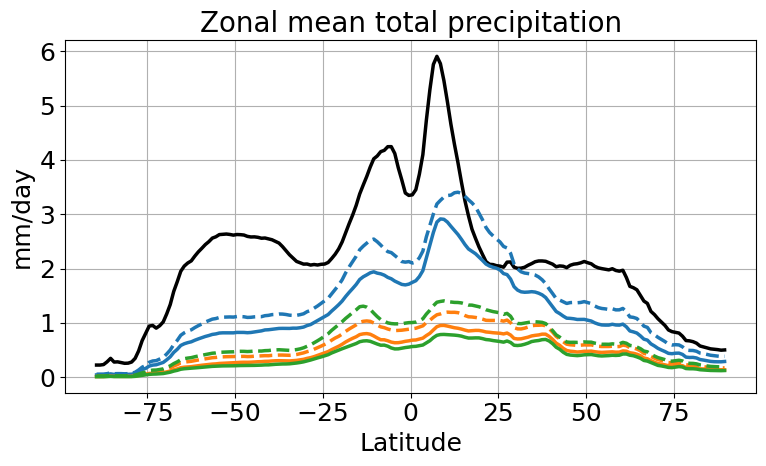

In [8]:
ds_list = [ds_ctr, ds_187_1co2, ds_187_2co2, ds_375_1co2, ds_375_2co2, ds_560_1co2, ds_560_2co2]
labels = ["Control", "1*CO₂ 187.5 cm⁻³", "2*CO₂ 187.5 cm⁻³", "1*CO₂ 375 cm⁻³", "2*CO₂ 375 cm⁻³", "1*CO₂ 560 cm⁻³", "2*CO₂ 560 cm⁻³"]

plot_zonal_mean(ds_list, labels, var="pr", title = 'Zonal mean total precipitation')

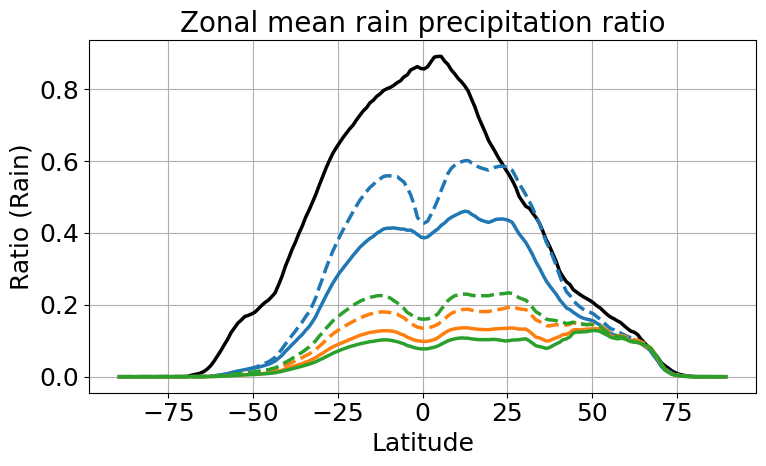

In [9]:
plot_convective_fraction(ds_list, labels, title='Zonal mean rain precipitation ratio')

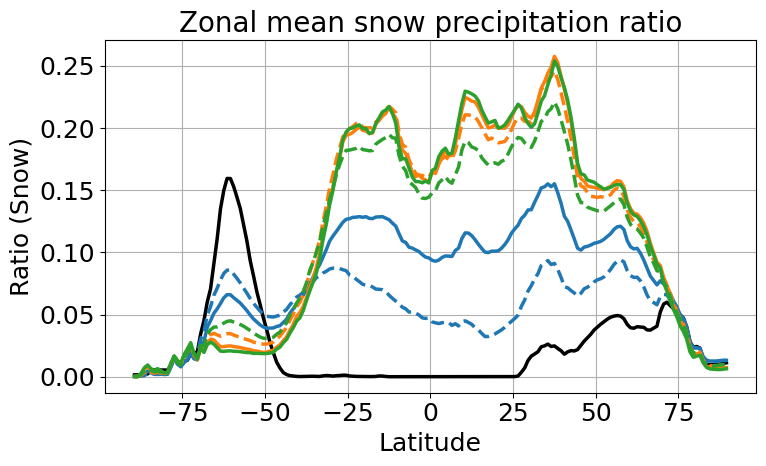

In [10]:
plot_stratiform_precipitation_fraction(ds_list, labels, title='Zonal mean snow precipitation ratio')